# Model Analysis and Visualization

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [2]:
# Load your dataset
data = pd.read_csv("basic_hand_landmarks.csv")

# Extract features (landmark coordinates) and labels
X = data.drop(columns=['label']).values  # Only coordinates
y = data['label'].values  # Labels

# Generate pairs (This example assumes binary labels for simplicity, modify as per your dataset)
def create_pairs(X, y):
    pairs = []
    labels = []
    unique_labels = np.unique(y)
    label_to_indices = {label: np.where(y == label)[0] for label in unique_labels}
    
    for label in unique_labels:
        indices = label_to_indices[label]
        num_indices = len(indices)
        
        # Positive pairs
        for i in range(num_indices):
            # Randomly select another sample from the same class
            j = np.random.choice(indices)
            pairs.append([X[indices[i]], X[j]])
            labels.append(1)  # Similar pair
        
        # Negative pairs
        for i in range(num_indices):
            # Select a different label
            different_label = np.random.choice(unique_labels[unique_labels != label])
            neg_index = np.random.choice(label_to_indices[different_label])
            pairs.append([X[indices[i]], X[neg_index]])
            labels.append(0)  # Dissimilar pair
    
    return np.array(pairs), np.array(labels)

pairs, labels = create_pairs(X, y)
pairs_train, pairs_test, labels_train, labels_test = train_test_split(pairs, labels, test_size=0.2, random_state=42)


In [3]:
len(pairs)

41814

In [4]:
from tensorflow.keras import layers, Model

def build_base_network(input_shape):
    input = layers.Input(shape=input_shape)
    
    # First dense layer with increased width
    x = layers.Dense(256, activation=None, kernel_initializer='he_normal')(input)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)  # Apply ReLU after Batch Normalization
   
    # Second dense layer
    x = layers.Dense(128, activation=None, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Third dense layer
    x = layers.Dense(128, activation=None, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Fourth dense layer
    x = layers.Dense(64, activation=None, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Fifth dense layer
    x = layers.Dense(256, activation=None, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Final embedding layer with 128 dimensions (no activation)
    x = layers.Dense(128, activation=None)(x)
    
    return Model(input, x)

input_shape = pairs_train.shape[2:]

base_network = build_base_network(input_shape)

# Inputs for the pairs
input_a = layers.Input(shape=input_shape)
input_b = layers.Input(shape=input_shape)

# Generate the embeddings for each input
embedding_a = base_network(input_a)
embedding_b = base_network(input_b)

# Compute the L2 distance between embeddings
distance = layers.Lambda(lambda embeddings: tf.reduce_sum(tf.square(embeddings[0] - embeddings[1]), axis=-1))([embedding_a, embedding_b])

# Siamese Network model
siamese_model = Model(inputs=[input_a, input_b], outputs=distance)


In [5]:
# Contrastive loss
def contrastive_loss(y_true, y_pred, margin=1.0):
    y_true = tf.cast(y_true, y_pred.dtype)
    positive_loss = y_true * tf.square(y_pred)
    negative_loss = (1 - y_true) * tf.square(tf.maximum(margin - y_pred, 0))
    return tf.reduce_mean(positive_loss + negative_loss)

# Custom accuracy
def accuracy(y_true, y_pred, threshold=1.0):
    print(f"{y_pred} < {threshold}")
    y_pred_labels = tf.cast(y_pred < threshold, tf.float32)
    return tf.reduce_mean(tf.cast(tf.equal(y_true, y_pred_labels), tf.float32))


In [6]:
# Load the trained model
base_network = tf.keras.models.load_model('embedding_model.h5',
                                          custom_objects={'contrastive_loss': contrastive_loss,
                                                         'accuracy': accuracy})

base_network.compile(optimizer='adam', loss=contrastive_loss, metrics=[accuracy])

In [7]:
# Extract embeddings
def get_embeddings(base_network, X):
    return base_network.predict(X)

# Convert string labels to numeric labels
def map_labels_to_numbers(labels):
    unique_labels = sorted(np.unique(labels))
    label_to_num = {label: idx for idx, label in enumerate(unique_labels)}
    numeric_labels = np.array([label_to_num[label] for label in labels])
    return numeric_labels, label_to_num


def plot_tsne(features, labels):
    unique_labels = np.unique(labels)
    labels_id = [np.where(unique_labels == label)[0][0] for label in labels]
    
    # Perform t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    features_2d = tsne.fit_transform(features)
    # Plotting the results
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=labels_id, cmap='viridis', alpha=0.5)

    # Calculate and plot class centers with labels
    unique_labels = np.unique(labels_id)
    for label in unique_labels:
        # Get points for this class
        mask = labels_id == label
        label_name = labels[np.where(labels_id == label)[0][0]]
        class_points = features_2d[mask]

        # Calculate center
        center = np.mean(class_points, axis=0)

        # Add text label slightly above center
        plt.text(center[0], center[1], f'{label_name}',
                  horizontalalignment='center',
                  verticalalignment='bottom',
                  fontweight='bold')

In [8]:
# Example usage
# Assuming you already have your data (X, y) and trained `base_network`
embeddings = get_embeddings(base_network, X)

# Optional: Provide class names if available
class_names = [chr(i) for i in range(ord('A'), ord('Z') + 1)] + ["Blank"]


654/654 [==============================] - 1s 2ms/step


In [9]:
import json
import numpy as np

def compute_class_means(model, X, y, classes):
    """Compute mean embeddings for each class."""
    class_means = {}
    for cls in classes:
        indices = np.where(y == cls)[0]
        embeddings = model.predict(X[indices])
        class_means[cls] = np.mean(embeddings, axis=0).tolist()
    
    # Save class means to a JSON file
    with open("class_means_aug_test_test.json", "w") as f:
        json.dump(class_means, f)
    print("Class means saved to class_means_aug_test_test.json")
    return class_means

# Assuming X and y are your dataset and labels
classes = np.unique(y)
class_means = compute_class_means(base_network, X, y, classes)


23/23 [==============================] - 0s 1ms/step
Class means saved to class_means_aug_test_test.json


In [10]:
{k: str(v) for k, v in class_means.items()}

{'A': '[0.006106154527515173, -0.012210831046104431, 0.1872585564851761, 0.00657836114987731, 0.0030201466288417578, -0.0117914704605937, 0.006970216054469347, -0.011834918521344662, 0.0038942655082792044, 0.22347334027290344, 0.15449517965316772, 0.006848879624158144, -0.00791550800204277, 0.0011281907791271806, 0.014917506836354733, 0.0009105961653403938, -0.010966860689222813, 0.0055885412730276585, -0.0021229537669569254, 0.005928907077759504, 0.012781776487827301, -0.0096701979637146, -0.013626476749777794, -0.011671405285596848, 0.009176732040941715, -0.004310489632189274, -0.006144839804619551, -0.006644347216933966, 0.004135427996516228, -0.09155858308076859, -0.011612786911427975, 0.011959482915699482, 0.004081356339156628, 0.014507000334560871, -0.008553117513656616, 0.015236813575029373, 0.004090702161192894, 0.008416183292865753, -0.0013677409151569009, 0.007904975675046444, 0.009030221961438656, -0.006815900560468435, -0.008183417841792107, 0.004282410256564617, -0.0125059

In [18]:
import os
from gesture_recognition import HandGestureRecognizer
import cv2
import numpy as np
from tqdm import tqdm
from contextlib import redirect_stdout

In [19]:
# Initialize the gesture recognizer
recognizer = HandGestureRecognizer("configs/old_model.yaml")

# Set up paths
dataset_path = "../kaggle/input/synthetic-asl-alphabet/Test_Alphabet"  # or Test_Alphabet
base_path = os.path.join(os.getcwd(), dataset_path)

# Get all class folders
class_folders = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]


In [20]:
# Process images and calculate accuracy
predictions = []
ground_truth = []
total_images = 0
correct = 0

# Process each class folder
for class_name in class_folders:
    class_path = os.path.join(base_path, class_name)
    image_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    
    class_correct = 0
    class_total = 0
    
    print(f"Processing class {class_name}...")
    for img_file in tqdm(image_files):
        img_path = os.path.join(class_path, img_file)
        
        # Read and process image
        img = cv2.imread(img_path)
        if img is None:
            continue
            
        # Process the image with stdout redirected
        with open(os.devnull, 'w') as devnull:
            with redirect_stdout(devnull):
                prediction = recognizer.process_frame(img)
        
        # Store results
        predictions.append(prediction)
        ground_truth.append(class_name)
        if prediction == class_name:
            correct += 1
            class_correct += 1
        total_images += 1
        class_total += 1
    
    # Print accuracy for this class
    class_accuracy = class_correct / class_total if class_total > 0 else 0
    print(f"Accuracy for {class_name}: {class_accuracy:.4f} ({class_correct}/{class_total})")

Processing class A...


100%|██████████| 100/100 [00:07<00:00, 13.85it/s]


Accuracy for A: 1.0000 (100/100)
Processing class B...


100%|██████████| 100/100 [00:07<00:00, 13.73it/s]


Accuracy for B: 1.0000 (100/100)
Processing class Blank...


...

Accuracy for Blank: 0.0000 (0/100)
Processing class C...


100%|██████████| 100/100 [00:07<00:00, 14.05it/s]


Accuracy for C: 0.9900 (99/100)
Processing class D...


 77%|███████▋  | 77/100 [00:05<00:01, 14.19it/s]


KeyboardInterrupt: 

In [15]:
# Calculate overall accuracy
overall_accuracy = correct / total_images
print(f"\nOverall Accuracy: {overall_accuracy:.4f}")

# Calculate accuracies by class
unique_labels = set(ground_truth)
unique_labels.add("No Class")
for label in unique_labels:
    mask = [l == label for l in ground_truth]
    class_predictions = [p for p, m in zip(predictions, mask) if m]
    class_total = sum(mask)
    class_correct = sum(p == label for p in class_predictions)
    class_accuracy = class_correct / class_total if class_total > 0 else 0
    print(f"Accuracy for class {label}: {class_accuracy:.4f}")


Overall Accuracy: 0.9196
Accuracy for class T: 0.9700
Accuracy for class A: 1.0000
Accuracy for class I: 0.9800
Accuracy for class Y: 1.0000
Accuracy for class O: 1.0000
Accuracy for class K: 1.0000
Accuracy for class G: 0.8900
Accuracy for class P: 0.9000
Accuracy for class S: 0.9700
Accuracy for class D: 0.9300
Accuracy for class M: 1.0000
Accuracy for class F: 0.9900
Accuracy for class E: 0.9900
Accuracy for class V: 1.0000
Accuracy for class R: 0.9800
Accuracy for class U: 0.9800
Accuracy for class W: 1.0000
Accuracy for class X: 0.9900
Accuracy for class B: 1.0000
Accuracy for class Q: 0.7600
Accuracy for class Blank: 0.0000
Accuracy for class C: 0.9900
Accuracy for class No Class: 0.0000
Accuracy for class H: 0.7000
Accuracy for class Z: 0.9900
Accuracy for class J: 0.8600
Accuracy for class N: 0.9600
Accuracy for class L: 1.0000


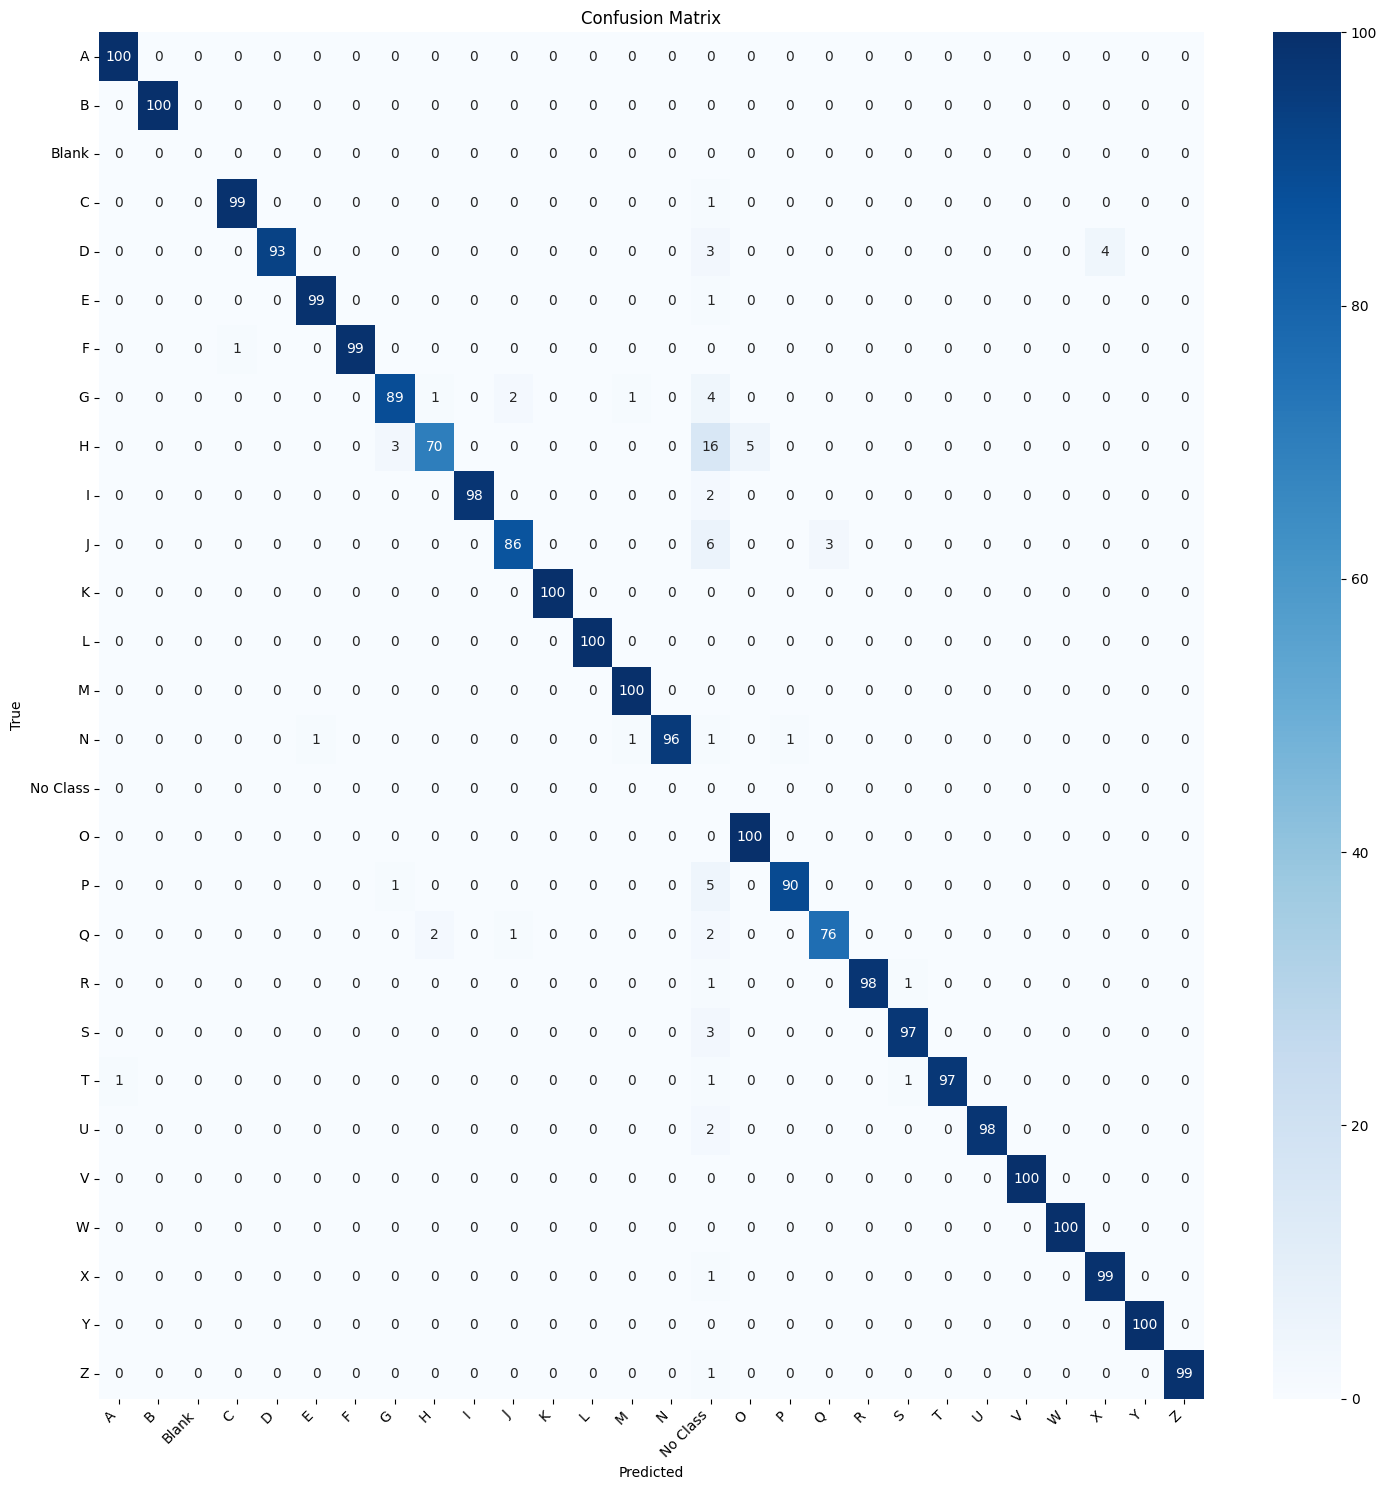

In [17]:
# Create and display confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get unique classes in sorted order
unique_classes = sorted(list(set(unique_labels)))

# Create confusion matrix
cm = confusion_matrix(ground_truth, predictions, labels=unique_classes)

# Create figure and axes
plt.figure(figsize=(15, 15))

# Create heatmap
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=unique_classes,
            yticklabels=unique_classes)

# Set labels
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

## t-SNE

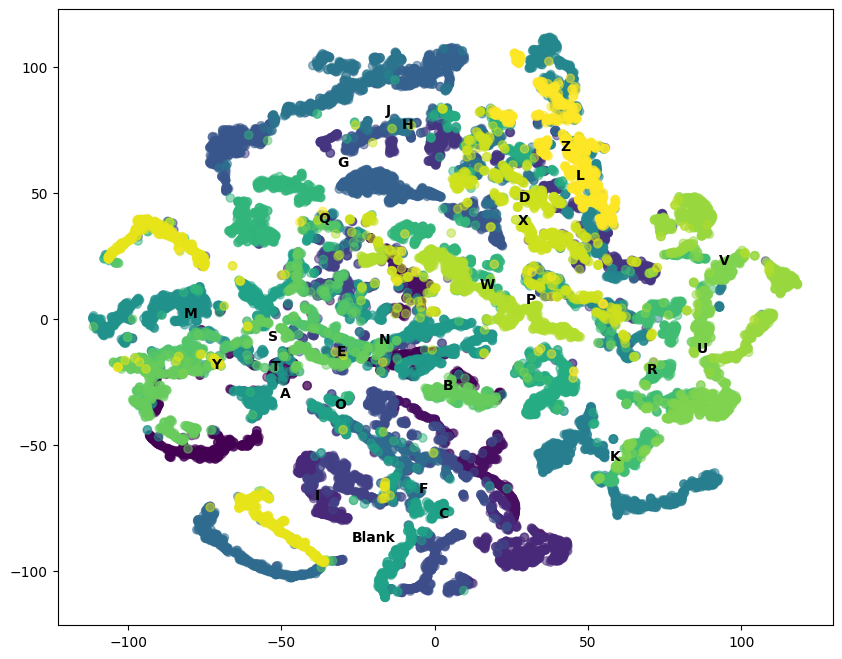

In [15]:
# Plot embeddings using t-SNE
plot_tsne(embeddings, y)

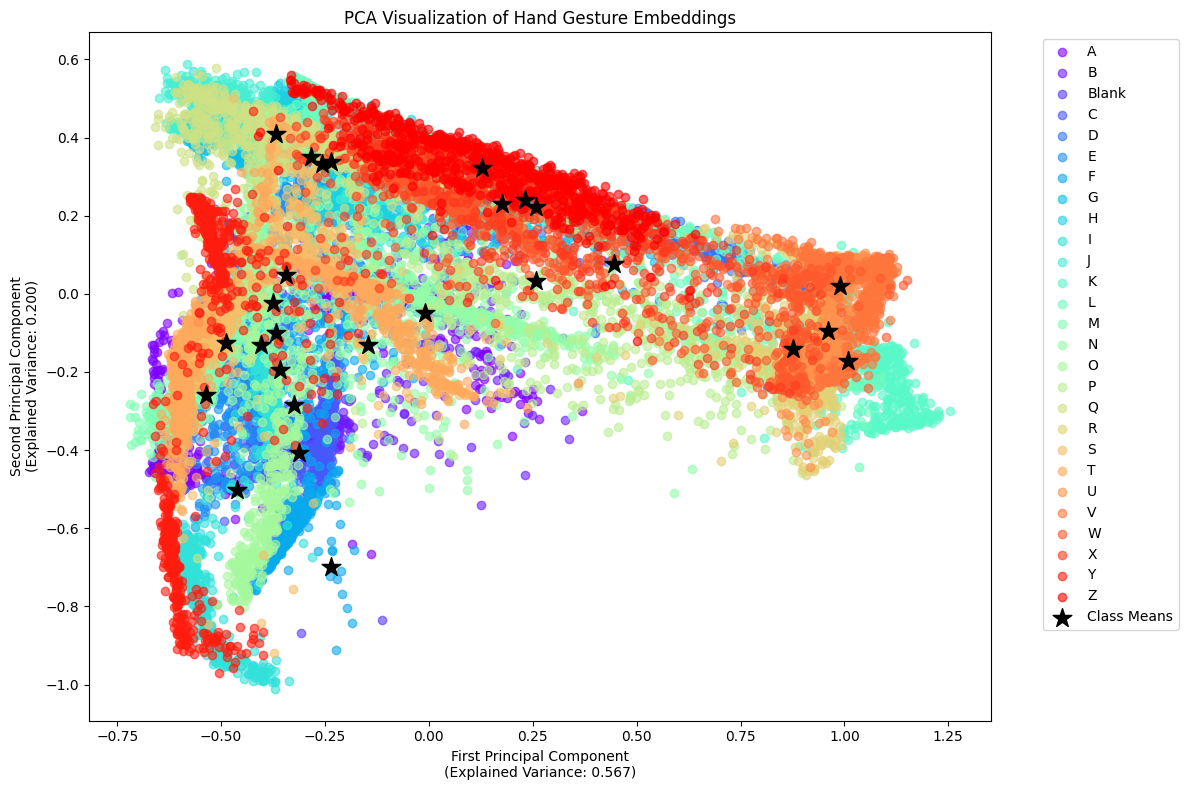

Total variance explained by first two components: 0.766


In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Assuming X is your embeddings array and y is your labels array
pca = PCA(n_components=2)
X_pca = pca.fit_transform(embeddings)

# Create scatter plot
plt.figure(figsize=(12, 8))

# Plot each class
unique_labels = np.unique(y)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    mask = y == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=[color], label=label, alpha=0.6)

# Plot class means
means_pca = pca.transform(np.array([class_means[label] for label in unique_labels]))
plt.scatter(means_pca[:, 0], means_pca[:, 1], 
            c='black', marker='*', s=200, label='Class Means')

plt.xlabel(f'First Principal Component\n(Explained Variance: {pca.explained_variance_ratio_[0]:.3f})')
plt.ylabel(f'Second Principal Component\n(Explained Variance: {pca.explained_variance_ratio_[1]:.3f})')
plt.title('PCA Visualization of Hand Gesture Embeddings')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print total explained variance
print(f"Total variance explained by first two components: {sum(pca.explained_variance_ratio_[:2]):.3f}")